In [ ]:
import yaml
import requests
import pandas as pd
import time

with open('creds.yaml', 'r') as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

# On récupère ton token avec le bon nom
api_key = config.get('token-openalex')

url = "https://api.openalex.org/works"

# 2. Paramètres de la requête
params = {
    "filter": "title_and_abstract.search:poker,publication_year:1950-2026   ",
    "per-page": 200,    
    "cursor": "*",      
    "api_key": api_key
}

all_works = []

print("Début de la collecte...")
while True:
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        print(f"Erreur API : {response.status_code}")
        break
        
    data = response.json()
    items = data.get('results', [])
    
    if not items:
        break
        
    all_works.extend(items)
    print(f"{len(all_works)} articles récupérés")
    
    next_cursor = data.get('meta', {}).get('next_cursor')
    if not next_cursor:
        break
        
    params['cursor'] = next_cursor
    time.sleep(0.1)

print(f"\n Nombre total d'articles : {len(all_works)}")

# 3. Création du DataFrame
df = pd.DataFrame(all_works)

Début de la collecte...
200 articles récupérés...
400 articles récupérés...
600 articles récupérés...
800 articles récupérés...
1000 articles récupérés...
1200 articles récupérés...
1400 articles récupérés...
1600 articles récupérés...
1800 articles récupérés...
2000 articles récupérés...
2200 articles récupérés...
2400 articles récupérés...
2600 articles récupérés...
2800 articles récupérés...
3000 articles récupérés...
3200 articles récupérés...
3400 articles récupérés...
3600 articles récupérés...
3800 articles récupérés...
4000 articles récupérés...
4200 articles récupérés...
4400 articles récupérés...
4600 articles récupérés...
4800 articles récupérés...
5000 articles récupérés...
5200 articles récupérés...
5400 articles récupérés...
5600 articles récupérés...
5800 articles récupérés...
6000 articles récupérés...
6200 articles récupérés...
6400 articles récupérés...
6600 articles récupérés...
6800 articles récupérés...
6953 articles récupérés...

Collecte terminée ! Nombre total d

--- Tableau : Répartition des articles par discipline ---
              Discipline  Nombre d'articles
0       Computer science               2303
1             Psychology                948
2                Physics                505
3                    Art                444
4      Political science                360
5  Environmental science                304
6                Geology                279
7               Business                266
8                History                253
9              Sociology                214


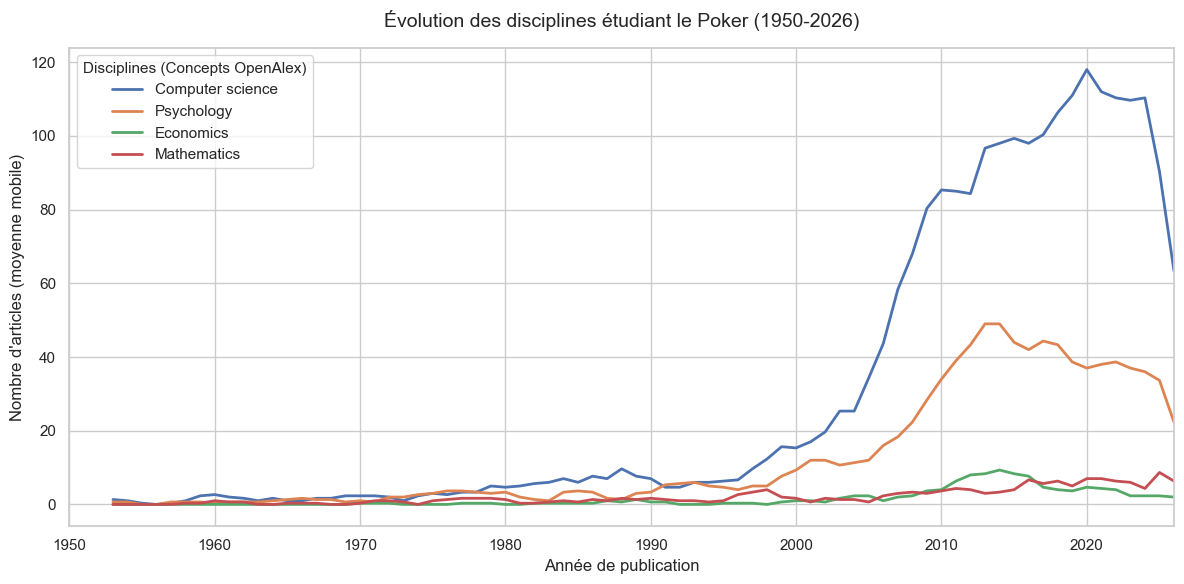

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fonction pour extraire la discipline principale (Concept de niveau 0)
def get_main_discipline(concepts_list):
    if not isinstance(concepts_list, list) or len(concepts_list) == 0:
        return "Inconnu"
    
    # On garde seulement les concepts très larges (niveau 0)
    level_0_concepts = [c for c in concepts_list if c.get('level') == 0]
    
    if level_0_concepts:
        # On prend celui qui a le score de pertinence le plus élevé
        best_concept = max(level_0_concepts, key=lambda x: x.get('score', 0))
        return best_concept.get('display_name')
    return "Inconnu"

# On applique la fonction pour créer une nouvelle colonne
df['discipline_principale'] = df['concepts'].apply(get_main_discipline)

# 2. Création du TABLEAU descriptif (Top 5 des disciplines)
print("--- Tableau : Répartition des articles par discipline ---")
tableau_disciplines = df['discipline_principale'].value_counts().reset_index()
tableau_disciplines.columns = ['Discipline', "Nombre d'articles"]
print(tableau_disciplines.head(10))

# 3. Préparation des données pour la VISUALISATION temporelle
# On compte le nombre d'articles par année et par discipline
evolution = df.groupby(['publication_year', 'discipline_principale']).size().unstack(fill_value=0)

# On sélectionne les 4 disciplines les plus pertinentes pour notre sujet
disciplines_a_suivre = ['Computer science', 'Psychology', 'Economics', 'Mathematics']
# (Vérifie bien que ces noms correspondent à ceux affichés dans ton tableau)

evolution_filtree = evolution[disciplines_a_suivre]

# 4. Création du GRAPHIQUE
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

for col in evolution_filtree.columns:
    # On lisse un peu les courbes avec une moyenne mobile sur 3 ans pour que ce soit plus joli
    plt.plot(evolution_filtree.index, evolution_filtree[col].rolling(window=3).mean(), label=col, linewidth=2)

plt.title("Évolution des disciplines étudiant le Poker (1950-2026)", fontsize=14, pad=15)
plt.xlabel("Année de publication", fontsize=12)
plt.ylabel("Nombre d'articles (moyenne mobile)", fontsize=12)
plt.legend(title="Disciplines (Concepts OpenAlex)", title_fontsize='11')
plt.xlim(1950, 2026)
plt.tight_layout()

# Affichage du graphique
plt.show()

In [26]:
import yaml
import requests
import json
import time
import pandas as pd

# 1. Chargement de la clé OpenRouter
with open('creds.yaml', 'r') as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

api_key_openrouter = config.get('token-openrouter')

if not api_key_openrouter:
    print("🚨 ERREUR : La clé 'token-openrouter' est introuvable dans creds.yaml !")
else:
    print("✅ Clé OpenRouter trouvée !")

# 2. Fonction pour appeler OpenRouter via requêtes HTTP
def classify_with_openrouter(abstract):
    url = "https://openrouter.ai/api/v1/chat/completions"
    
    headers = {
        "Authorization": f"Bearer {api_key_openrouter}",
        "Content-Type": "application/json"
    }
    
    prompt = f"""
    Tu es un chercheur en sociologie des sciences. Lis le résumé d'article scientifique suivant.
    Classe cet article dans UNE SEULE de ces trois catégories en fonction de son objectif principal :
    1. "Comportement" (Si l'étude porte sur la psychologie, l'addiction, ou le comportement humain)
    2. "Théorie" (Si l'étude porte sur les mathématiques pures ou l'économie classique)
    3. "IA" (Si l'étude porte sur les algorithmes, l'informatique, les réseaux de neurones ou la résolution par machine)
    
    Réponds UNIQUEMENT par le mot de la catégorie ("Comportement", "Théorie", ou "IA"). Pas de phrases supplémentaires.
    
    Résumé : {abstract}
    """
    
    data = {
            # Cet alias permet à OpenRouter de router vers le meilleur modèle gratuit disponible
            "model": "openrouter/auto", 
            "messages": [{"role": "user", "content": prompt}],
            "temperature": 0.0
        }
    
    try:
        response = requests.post(url, headers=headers, json=data)
        if response.status_code == 200:
            result = response.json()
            return result['choices'][0]['message']['content'].strip()
        else:
            print(f"Erreur HTTP: {response.status_code} - {response.text}")
            return "Erreur"
    except Exception as e:
        print(f"Erreur de connexion : {e}")
        return "Erreur"

# 3. Boucle d'exécution sur notre échantillon
print(f"\nDébut du traitement de l'échantillon de {len(df_sample)} articles...")
results = []

for i, (index, row) in enumerate(df_sample.iterrows()):
    category = classify_with_openrouter(row['abstract'])
    results.append(category)
    
    # Affichage régulier
    if (i + 1) % 10 == 0:
        print(f"{i + 1} articles traités sur {len(df_sample)}...")
        
    time.sleep(1)

df_sample['llm_category'] = results
print("\nTraitement terminé !")

# 4. Affichage final
print("\n--- Répartition en pourcentage (False = Avant 2010 | True = Après 2015) ---")
print(pd.crosstab(df_sample['publication_year'] > 2015, df_sample['llm_category'], normalize='index') * 100)

✅ Clé OpenRouter trouvée !

Début du traitement de l'échantillon de 200 articles...
10 articles traités sur 200...
20 articles traités sur 200...
30 articles traités sur 200...
40 articles traités sur 200...
50 articles traités sur 200...
60 articles traités sur 200...
70 articles traités sur 200...
80 articles traités sur 200...
90 articles traités sur 200...
100 articles traités sur 200...
110 articles traités sur 200...
120 articles traités sur 200...
130 articles traités sur 200...
140 articles traités sur 200...
150 articles traités sur 200...
160 articles traités sur 200...
170 articles traités sur 200...
180 articles traités sur 200...
190 articles traités sur 200...
200 articles traités sur 200...

Traitement terminé !

--- Répartition en pourcentage (False = Avant 2010 | True = Après 2015) ---
llm_category      **IA**  Comportement    IA  Théorie
publication_year                                     
False                0.0          43.0  35.0     22.0
True                 2.0

--- TABLEAU RÉCAPITULATIF (en %) ---


llm_category,Comportement,Théorie,IA
Avant 2010,43.0%,22.0%,35.0%
Après 2015,40.0%,10.0%,50.0%


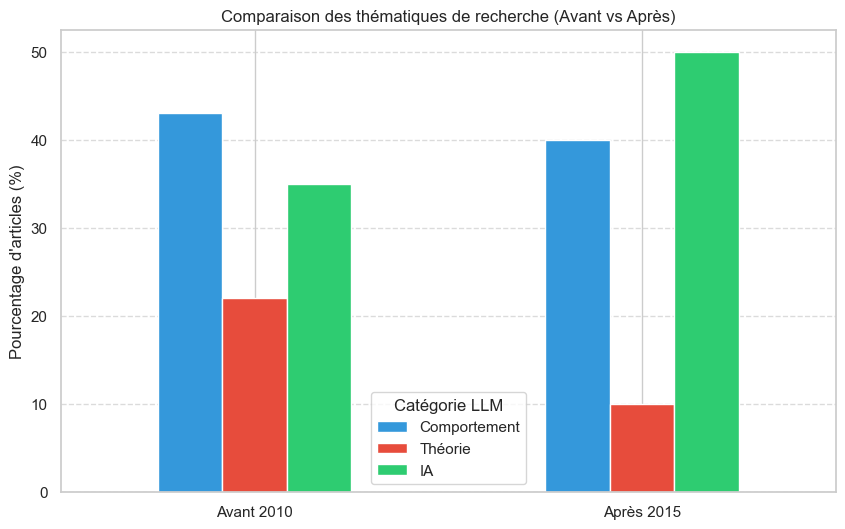

In [27]:
# 1. On recrée le tableau de contingence (crosstab)
tableau_final = pd.crosstab(
    df_sample['publication_year'] > 2015, 
    df_sample['llm_category'], 
    normalize='index'
) * 100

# 2. NETTOYAGE : Si le LLM a mis des étoiles ou des variantes, on fusionne les colonnes IA
# On cherche toutes les colonnes qui contiennent "IA"
colonnes_ia = [c for c in tableau_final.columns if 'IA' in c]
if len(colonnes_ia) > 1:
    tableau_final['IA_clean'] = tableau_final[colonnes_ia].sum(axis=1)
    tableau_final = tableau_final.drop(columns=colonnes_ia)
    tableau_final = tableau_final.rename(columns={'IA_clean': 'IA'})

# 3. MISE EN FORME : On renomme les lignes pour le rapport
tableau_final.index = ['Avant 2010', 'Après 2015']

# 4. AFFICHAGE "CLEAN" avec style
print("--- TABLEAU RÉCAPITULATIF (en %) ---")
# On utilise .style pour mettre de la couleur (fonctionne dans les notebooks VSCode)
styled_table = tableau_final.style.format("{:.1f}%") \
    .background_gradient(cmap='Blues', axis=1) \
    .set_caption("Évolution de l'intention de recherche sur le Poker (Analyse par LLM)")

display(styled_table)

# Si tu veux aussi un petit graphique à barres comparatif (très utile pour le rapport !)
tableau_final.plot(kind='bar', figsize=(10, 6), rot=0, color=['#3498db', '#e74c3c', '#2ecc71'])
import matplotlib.pyplot as plt
plt.title("Comparaison des thématiques de recherche (Avant vs Après)")
plt.ylabel("Pourcentage d'articles (%)")
plt.legend(title="Catégorie LLM")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()